Carregando os dados

In [83]:
# importando todas as bibliotecas importantes para cálculo e criação de visualização gráfica
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import plotly.express as px
from pandas.plotting import scatter_matrix
from sklearn import model_selection
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

# importando o arquivo
df = pd.read_csv('Base_Treinamento.csv', sep=',')
df.head()

,id,data_criacao,tipo_chamado,dias_problema,risco_vida_humana,risco_vida_animal,bloqueio_via,urgencia
0,BCS-00163074,2026-02-22 10:34:58.338000+00:00,Outros Problemas com Postes,51,Sim,Não,Não,URGENTE
1,BCS-00172400,2026-03-07 09:40:54.637000+00:00,Outros Problemas com Postes,38,Não,Sim,Não,ALTA
2,BCS-00166754,2026-02-25 09:02:46.448000+00:00,Luz Queimada Poste,48,Sim,Não,Sim,URGENTE
3,BCS-00171257,2026-03-04 23:15:53.768443+00:00,Luz Queimada Poste,41,Sim,Não,Sim,URGENTE
4,BCS-00065327,2025-08-01 06:35:06.539000+00:00,Problema com Animal Doméstico,256,Sim,Não,Não,URGENTE


Tratamento dos Dados

In [84]:
# Remoção de colunas desnecessárias
df = df.drop(columns=['id', 'data_criacao'])

# Mapeamento e conversão automática para tipo_chamado
mapeamento_tipo = {tipo: i for i, tipo in enumerate(df['tipo_chamado'].unique())}
df['tipo_chamado'] = df['tipo_chamado'].map(mapeamento_tipo)

# Mapeamento e conversão automática para urgencia (classe)
mapeamento_urgencia = {urgencia: i for i, urgencia in enumerate(df['urgencia'].unique())}
df['urgencia'] = df['urgencia'].map(mapeamento_urgencia)

# Conversão das colunas Sim/Não
for coluna in ['risco_vida_humana', 'risco_vida_animal', 'bloqueio_via']:
    df[coluna] = df[coluna].map({'Sim': 1, 'Não': 0})

# Relatório em formato de tabela - tipo_chamado
print("\n" + "="*75)
print("TABELA DE CONVERSÃO - tipo_chamado")
print("="*75)
print(f"{'Valor Original':<40} {'->':<5} {'Valor Numérico':<15}")
print("-"*75)
for tipo, numero in mapeamento_tipo.items():
    print(f"{str(tipo):<40} {'->':<5} {str(numero):<15}")
print("="*75)

# Relatório em formato de tabela - urgencia (classe)
print("\n" + "="*75)
print("TABELA DE CONVERSÃO - urgencia (CLASSE)")
print("="*75)
print(f"{'Valor Original':<40} {'->':<5} {'Valor Numérico':<15}")
print("-"*75)
for urgencia, numero in mapeamento_urgencia.items():
    print(f"{str(urgencia):<40} {'->':<5} {str(numero):<15}")
print("="*75)

# Relatório das colunas Sim/Não
print("\n" + "="*75)
print("TABELA DE CONVERSÃO - Sim/Não")
print("="*75)
print(f"{'Valor Original':<20} {'->':<5} {'Valor Numérico':<15}")
print("-"*75)
print(f"{'Sim':<20} {'->':<5} {'1':<15}")
print(f"{'Não':<20} {'->':<5} {'0':<15}")
print("="*75)
print(f"Colunas convertidas: risco_vida_humana, risco_vida_animal, bloqueio_via")
print("="*75)
print("")

# Exibir informações sobre os dados convertidos
print("\n" + "="*75)
print("RESUMO DAS CONVERSÕES REALIZADAS")
print("="*75)
print(f"✓ tipo_chamado: {len(mapeamento_tipo)} categorias convertidas")
print(f"✓ urgencia (classe): {len(mapeamento_urgencia)} categorias convertidas")
print(f"✓ risco_vida_humana: Sim/Não convertido para 1/0")
print(f"✓ risco_vida_animal: Sim/Não convertido para 1/0")
print(f"✓ bloqueio_via: Sim/Não convertido para 1/0")
print("="*75)

# Mostrar tipos de dados após conversão
print("\nTIPOS DE DADOS APÓS CONVERSÃO:")
print(df.dtypes)
print("")


TABELA DE CONVERSÃO - tipo_chamado
Valor Original                           ->    Valor Numérico 
---------------------------------------------------------------------------
Outros Problemas com Postes              ->    0              
Luz Queimada Poste                       ->    1              
Problema com Animal Doméstico            ->    2              
Problema com Animal Selvagem             ->    3              
Animal Perdido                           ->    4              
Remoção de Árvore ou Tocos               ->    5              
Poste caido                              ->    6              
Divisor de Pista                         ->    7              
Árvore ou Galhos Caídos                  ->    8              
Solicitação de Poda                      ->    9              
Solicitação de Plantio                   ->    10             
Lixo e Detritos                          ->    11             
Manutenção da Área Verde                 ->    12             
Sugest

Informações

In [85]:
# Dimensão
print(df.shape)

(8639, 6)


In [86]:
# Resumo estatístico
print(df.describe())

       tipo_chamado  dias_problema  risco_vida_humana  risco_vida_animal  \
count   8639.000000    8639.000000        8639.000000        8639.000000   
mean       3.650075     102.274453           0.479106           0.489293   
std        3.538450      69.939221           0.499592           0.499914   
min        0.000000       1.000000           0.000000           0.000000   
25%        1.000000      36.000000           0.000000           0.000000   
50%        2.000000      97.000000           0.000000           0.000000   
75%        6.000000     157.500000           1.000000           1.000000   
max       21.000000     256.000000           1.000000           1.000000   

       bloqueio_via     urgencia  
count   8639.000000  8639.000000  
mean       0.460586     0.519620  
std        0.498473     0.827185  
min        0.000000     0.000000  
25%        0.000000     0.000000  
50%        0.000000     0.000000  
75%        1.000000     1.000000  
max        1.000000     3.000000  


In [87]:
# Distribuição de classe
print(df.groupby('urgencia').size())

urgencia
0    5772
1    1500
2    1112
3     255
dtype: int64


Visualização dos dados

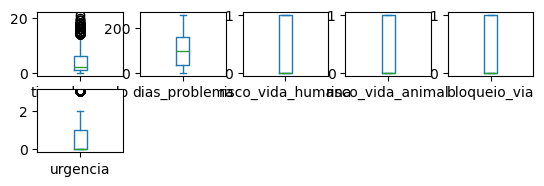

In [89]:
# gráfico de box and whisker
df.plot(kind='box', subplots=True, layout=(5,5), sharex=False, sharey=False)
plt.show()

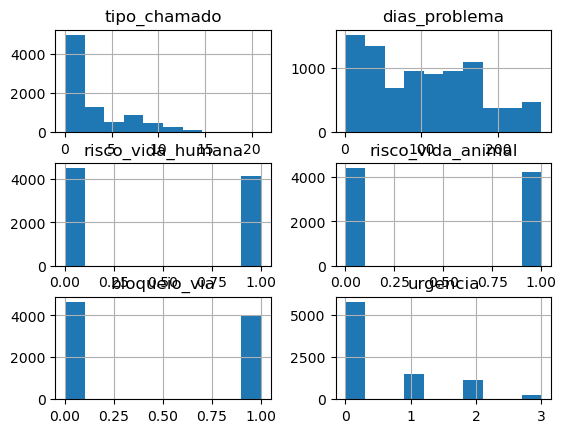

In [88]:
# histograma
df.hist()
plt.show()

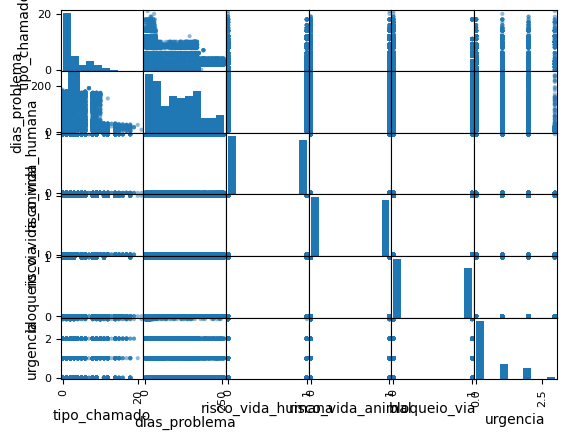

In [90]:
# gráfico de dispersão
scatter_matrix(df)
plt.show()

Criar conjunto de validação

In [91]:
# Separar features e target
X = df.drop('urgencia', axis=1).values
Y = df['urgencia'].values

# Normalizar os dados (crucial para SVM e KNN)
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Dividir em treino e validação
validation_size = 0.20
seed = 7
X_train, X_validation, Y_train, Y_validation = model_selection.train_test_split(X, Y, test_size=validation_size, random_state=seed, stratify=Y)

print("Shape X_train:", X_train.shape)
print("Shape Y_train:", Y_train.shape)
print("Shape X_validation:", X_validation.shape)
print("Shape Y_validation:", Y_validation.shape)
print("\nDistribuição classes no treino:", np.bincount(Y_train))
print("Distribuição classes na validação:", np.bincount(Y_validation))

Shape X_train: (6911, 5)
Shape Y_train: (6911,)
Shape X_validation: (1728, 5)
Shape Y_validation: (1728,)

Distribuição classes no treino: [4617 1200  890  204]
Distribuição classes na validação: [1155  300  222   51]


In [92]:
# Métricas
seed = 7
scoring = 'accuracy'

### Algoritmos que serão treinados
##### Regressão Logística (LR)
##### Análise Linear Discriminante (LDA)
##### K-vizinhos mais próximos (KNN)
##### Árvores de Classificação (Decision Tree) e Regressão (CART)
##### Gaussian Naive Bayes (NB)
##### Support Vector Machines (SVM)

In [93]:
# Algoritmos
models = []
models.append(('LR', LogisticRegression(solver='liblinear', multi_class='ovr', max_iter=1000)))
models.append(('LDA', LinearDiscriminantAnalysis()))
models.append(('KNN', KNeighborsClassifier()))
models.append(('CART', DecisionTreeClassifier(max_depth=10, random_state=seed)))
models.append(('NB', GaussianNB()))
models.append(('SVM', SVC(gamma='auto')))

# Avaliação de cada modelo
results = []
names = []
for name, model in models:
   kfold = model_selection.KFold(n_splits=10, shuffle=True, random_state=seed)
   cv_results = model_selection.cross_val_score(model, X_train, Y_train, cv=kfold, scoring=scoring)
   results.append(cv_results)
   names.append(name)
   msg = '%s: %f (%f)' % (name, cv_results.mean(), cv_results.std())
   print(msg)

LR: 0.784834 (0.016266)
LDA: 0.787005 (0.016191)
KNN: 0.817392 (0.010416)
CART: 0.825783 (0.015779)
NB: 0.758063 (0.068122)
SVM: 0.798581 (0.019432)


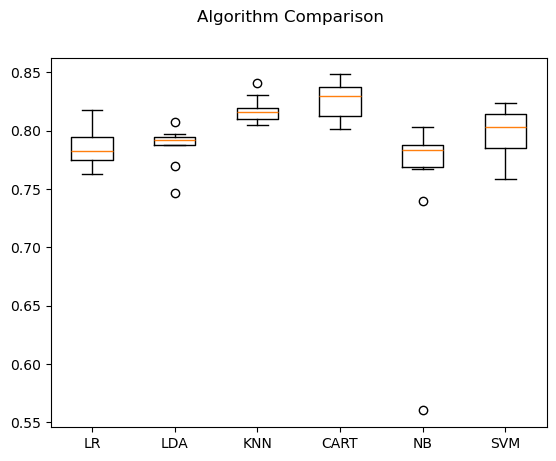

In [94]:
# Comparação dos Algoritmos
fig = plt.figure()
fig.suptitle('Algorithm Comparison')
ax = fig.add_subplot(111)
plt.boxplot(results)
ax.set_xticklabels(names)
plt.show()

KNN

In [108]:
# Precisão do modelo no conjunto de treinamento
knn = KNeighborsClassifier()
knn.fit(X_train, Y_train)
predictions = knn.predict(X_train)
print("Acurácia Treino:", accuracy_score(Y_train, predictions))
print("Matriz de Confusão (Treino):")
print(confusion_matrix(Y_train, predictions))
print("Relatório (Treino):")
print(classification_report(Y_train, predictions))

Acurácia Treino: 0.8690493416292866
Matriz de Confusão (Treino):
[[4426  183    8    0]
 [ 237  793  169    1]
 [  23  173  668   26]
 [   1   16   68  119]]
Relatório (Treino):
              precision    recall  f1-score   support

           0       0.94      0.96      0.95      4617
           1       0.68      0.66      0.67      1200
           2       0.73      0.75      0.74       890
           3       0.82      0.58      0.68       204

    accuracy                           0.87      6911
   macro avg       0.79      0.74      0.76      6911
weighted avg       0.87      0.87      0.87      6911



In [107]:
# Precisão do modelo no conjunto de validação
knn = KNeighborsClassifier()
knn.fit(X_train, Y_train)
predictions = knn.predict(X_validation)
print("Acurácia Validação:", accuracy_score(Y_validation, predictions))
print("Matriz de Confusão (Validação):")
print(confusion_matrix(Y_validation, predictions))
print("Relatório (Validação):")
print(classification_report(Y_validation, predictions))

Acurácia Validação: 0.8130787037037037
Matriz de Confusão (Validação):
[[1081   70    4    0]
 [  85  159   56    0]
 [   7   69  140    6]
 [   0    5   21   25]]
Relatório (Validação):
              precision    recall  f1-score   support

           0       0.92      0.94      0.93      1155
           1       0.52      0.53      0.53       300
           2       0.63      0.63      0.63       222
           3       0.81      0.49      0.61        51

    accuracy                           0.81      1728
   macro avg       0.72      0.65      0.67      1728
weighted avg       0.81      0.81      0.81      1728



LR

In [109]:
# Precisão do modelo no conjunto de treinamento
lr = LogisticRegression(solver='liblinear', multi_class='ovr', max_iter=1000)
lr.fit(X_train, Y_train)
predictions = lr.predict(X_train)
print("Acurácia Treino:", accuracy_score(Y_train, predictions))
print("Matriz de Confusão (Treino):")
print(confusion_matrix(Y_train, predictions))
print("Relatório (Treino):")
print(classification_report(Y_train, predictions))

Acurácia Treino: 0.7846910722037331
Matriz de Confusão (Treino):
[[4476  137    4    0]
 [ 654  304  242    0]
 [ 115  133  642    0]
 [  18   17  168    1]]
Relatório (Treino):
              precision    recall  f1-score   support

           0       0.85      0.97      0.91      4617
           1       0.51      0.25      0.34      1200
           2       0.61      0.72      0.66       890
           3       1.00      0.00      0.01       204

    accuracy                           0.78      6911
   macro avg       0.74      0.49      0.48      6911
weighted avg       0.77      0.78      0.75      6911



In [111]:
# Precisão do modelo no conjunto de validação
lr = LogisticRegression(solver='liblinear', multi_class='ovr', max_iter=1000)
lr.fit(X_train, Y_train)
predictions = lr.predict(X_validation)
print("Acurácia Validação:", accuracy_score(Y_validation, predictions))
print("Matriz de Confusão (Validação):")
print(confusion_matrix(Y_validation, predictions))
print("Relatório (Validação):")
print(classification_report(Y_validation, predictions))

Acurácia Validação: 0.7824074074074074
Matriz de Confusão (Validação):
[[1126   28    1    0]
 [ 175   69   56    0]
 [  35   30  157    0]
 [   2    4   45    0]]
Relatório (Validação):
              precision    recall  f1-score   support

           0       0.84      0.97      0.90      1155
           1       0.53      0.23      0.32       300
           2       0.61      0.71      0.65       222
           3       0.00      0.00      0.00        51

    accuracy                           0.78      1728
   macro avg       0.49      0.48      0.47      1728
weighted avg       0.73      0.78      0.74      1728



c:\Users\luisp\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\luisp\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\luisp\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


LDA

In [112]:
# Precisão do modelo no conjunto de treinamento
lda = LinearDiscriminantAnalysis()
lda.fit(X_train, Y_train)
predictions = lda.predict(X_train)
print("Acurácia Treino:", accuracy_score(Y_train, predictions))
print("Matriz de Confusão (Treino):")
print(confusion_matrix(Y_train, predictions))
print("Relatório (Treino):")
print(classification_report(Y_train, predictions))

Acurácia Treino: 0.789755462306468
Matriz de Confusão (Treino):
[[4306  303    4    4]
 [ 467  486  236   11]
 [  58  182  603   47]
 [   1   30  110   63]]
Relatório (Treino):
              precision    recall  f1-score   support

           0       0.89      0.93      0.91      4617
           1       0.49      0.41      0.44      1200
           2       0.63      0.68      0.65       890
           3       0.50      0.31      0.38       204

    accuracy                           0.79      6911
   macro avg       0.63      0.58      0.60      6911
weighted avg       0.78      0.79      0.78      6911



In [113]:
# Precisão do modelo no conjunto de validação
lda = LinearDiscriminantAnalysis()
lda.fit(X_train, Y_train)
predictions = lda.predict(X_validation)
print("Acurácia Validação:", accuracy_score(Y_validation, predictions))
print("Matriz de Confusão (Validação):")
print(confusion_matrix(Y_validation, predictions))
print("Relatório (Validação):")
print(classification_report(Y_validation, predictions))

Acurácia Validação: 0.7945601851851852
Matriz de Confusão (Validação):
[[1089   65    1    0]
 [ 120  123   55    2]
 [  20   41  149   12]
 [   0    6   33   12]]
Relatório (Validação):
              precision    recall  f1-score   support

           0       0.89      0.94      0.91      1155
           1       0.52      0.41      0.46       300
           2       0.63      0.67      0.65       222
           3       0.46      0.24      0.31        51

    accuracy                           0.79      1728
   macro avg       0.62      0.56      0.58      1728
weighted avg       0.78      0.79      0.78      1728



CART

In [114]:
# Precisão do modelo no conjunto de treinamento
cart = DecisionTreeClassifier(max_depth=10, random_state=seed)
cart.fit(X_train, Y_train)
predictions = cart.predict(X_train)
print("Acurácia Treino:", accuracy_score(Y_train, predictions))
print("Matriz de Confusão (Treino):")
print(confusion_matrix(Y_train, predictions))
print("Relatório (Treino):")
print(classification_report(Y_train, predictions))

Acurácia Treino: 0.8755607003328028
Matriz de Confusão (Treino):
[[4448  158   11    0]
 [ 241  743  214    2]
 [   7  139  719   25]
 [   0    7   56  141]]
Relatório (Treino):
              precision    recall  f1-score   support

           0       0.95      0.96      0.96      4617
           1       0.71      0.62      0.66      1200
           2       0.72      0.81      0.76       890
           3       0.84      0.69      0.76       204

    accuracy                           0.88      6911
   macro avg       0.80      0.77      0.78      6911
weighted avg       0.87      0.88      0.87      6911



In [115]:
# Precisão do modelo no conjunto de validação
cart = DecisionTreeClassifier(max_depth=10, random_state=seed)
cart.fit(X_train, Y_train)
predictions = cart.predict(X_validation)
print("Acurácia Validação:", accuracy_score(Y_validation, predictions))
print("Matriz de Confusão (Validação):")
print(confusion_matrix(Y_validation, predictions))
print("Relatório (Validação):")
print(classification_report(Y_validation, predictions))

Acurácia Validação: 0.8258101851851852
Matriz de Confusão (Validação):
[[1092   61    2    0]
 [  77  156   66    1]
 [   6   53  150   13]
 [   0    1   21   29]]
Relatório (Validação):
              precision    recall  f1-score   support

           0       0.93      0.95      0.94      1155
           1       0.58      0.52      0.55       300
           2       0.63      0.68      0.65       222
           3       0.67      0.57      0.62        51

    accuracy                           0.83      1728
   macro avg       0.70      0.68      0.69      1728
weighted avg       0.82      0.83      0.82      1728



NB

In [116]:
# Precisão do modelo no conjunto de treinamento
nb = GaussianNB()
nb.fit(X_train, Y_train)
predictions = nb.predict(X_train)
print("Acurácia Treino:", accuracy_score(Y_train, predictions))
print("Matriz de Confusão (Treino):")
print(confusion_matrix(Y_train, predictions))
print("Relatório (Treino):")
print(classification_report(Y_train, predictions))

Acurácia Treino: 0.7799160758211546
Matriz de Confusão (Treino):
[[4454  154    7    2]
 [ 641  272  250   37]
 [ 100   99  531  160]
 [  15    7   49  133]]
Relatório (Treino):
              precision    recall  f1-score   support

           0       0.85      0.96      0.91      4617
           1       0.51      0.23      0.31      1200
           2       0.63      0.60      0.61       890
           3       0.40      0.65      0.50       204

    accuracy                           0.78      6911
   macro avg       0.60      0.61      0.58      6911
weighted avg       0.75      0.78      0.75      6911



In [117]:
# Precisão do modelo no conjunto de validação
nb = GaussianNB()
nb.fit(X_train, Y_train)
predictions = nb.predict(X_validation)
print("Acurácia Validação:", accuracy_score(Y_validation, predictions))
print("Matriz de Confusão (Validação):")
print(confusion_matrix(Y_validation, predictions))
print("Relatório (Validação):")
print(classification_report(Y_validation, predictions))

Acurácia Validação: 0.7789351851851852
Matriz de Confusão (Validação):
[[1115   39    1    0]
 [ 173   62   55   10]
 [  27   28  131   36]
 [   1    2   10   38]]
Relatório (Validação):
              precision    recall  f1-score   support

           0       0.85      0.97      0.90      1155
           1       0.47      0.21      0.29       300
           2       0.66      0.59      0.63       222
           3       0.45      0.75      0.56        51

    accuracy                           0.78      1728
   macro avg       0.61      0.63      0.59      1728
weighted avg       0.75      0.78      0.75      1728



SVM

In [118]:
# Precisão do modelo no conjunto de treinamento
svm = SVC(gamma='auto')
svm.fit(X_train, Y_train)
predictions = svm.predict(X_train)
print("Acurácia Treino:", accuracy_score(Y_train, predictions))
print("Matriz de Confusão (Treino):")
print(confusion_matrix(Y_train, predictions))
print("Relatório (Treino):")
print(classification_report(Y_train, predictions))

Acurácia Treino: 0.8052380263348285
Matriz de Confusão (Treino):
[[4368  242    7    0]
 [ 465  468  266    1]
 [  87  122  656   25]
 [  18    6  107   73]]
Relatório (Treino):
              precision    recall  f1-score   support

           0       0.88      0.95      0.91      4617
           1       0.56      0.39      0.46      1200
           2       0.63      0.74      0.68       890
           3       0.74      0.36      0.48       204

    accuracy                           0.81      6911
   macro avg       0.70      0.61      0.63      6911
weighted avg       0.79      0.81      0.79      6911



In [119]:
# Precisão do modelo no conjunto de validação
svm = SVC(gamma='auto')
svm.fit(X_train, Y_train)
predictions = svm.predict(X_validation)
print("Acurácia Validação:", accuracy_score(Y_validation, predictions))
print("Matriz de Confusão (Validação):")
print(confusion_matrix(Y_validation, predictions))
print("Relatório (Validação):")
print(classification_report(Y_validation, predictions))

Acurácia Validação: 0.8084490740740741
Matriz de Confusão (Validação):
[[1104   50    1    0]
 [ 119  121   60    0]
 [  23   36  156    7]
 [   2    1   32   16]]
Relatório (Validação):
              precision    recall  f1-score   support

           0       0.88      0.96      0.92      1155
           1       0.58      0.40      0.48       300
           2       0.63      0.70      0.66       222
           3       0.70      0.31      0.43        51

    accuracy                           0.81      1728
   macro avg       0.70      0.59      0.62      1728
weighted avg       0.79      0.81      0.79      1728



Algoritmo Escolhido

Como modelo para o nosso projeto, foi escolhido o CART pois apresenta os melhores resultados de precisão para treinamento (87%) e teste (82%).